# DUNE with the official TDR simulation (GLoBES configuration)

In `realistic_event_rates.ipynb` DUNE events were computed with a linear cross section,
100% efficiency and a toy Gaussian resolution. DUNE has published the configuration it uses
for fast sensitivity studies with GLoBES
(DUNE Collaboration, *Experiment Simulation Configurations Approximating DUNE TDR*,
[arXiv:2103.04797](https://arxiv.org/abs/2103.04797)); the ancillary files are in
`data/DUNE_GLoBES_2103.04797/`.

`nuosc.dune_globes.DUNEGlobes` re-implements the GLoBES recipe in a few lines of numpy:

$$
N_i = \varepsilon_i \sum_k S_{ik}\; \underbrace{\mathcal{N}\,\Phi_\alpha(E_k)\,\sigma_\beta(E_k)\,
P_{\alpha\beta}(E_k)\,\Delta E_k}_{\text{events in true bin }k},
$$

with the DUNE flux $\Phi$, GENIE cross sections on argon $\sigma$, migration (smearing) matrices
$S_{ik}$ from true to reconstructed energy and selection efficiencies $\varepsilon_i$.
Oscillation probabilities come from our NuFast implementation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from nuosc import NeutrinoOscillator, cross_section_cc, expected_events, group_rates, histogram
from nuosc.dune_globes import DUNEGlobes, DUNE_GLOBES_DIR

from nuosc.plotting import set_style
SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

SAMPLE_LABEL = {"nue_app": r"$\nu_e$ appearance (FHC)", "nuebar_app": r"$\bar\nu_e$ appearance (RHC)",
                "numu_dis": r"$\nu_\mu$ disappearance (FHC)", "numubar_dis": r"$\bar\nu_\mu$ disappearance (RHC)"}
PAPER_DIR = DUNE_GLOBES_DIR.parent        # figures of arXiv:2103.04797

## 0. Configuration

In [2]:
# ------------------------------------------------------------------ #
YEARS_FHC = 6.5     # years of neutrino running   (config default: 6.5 -> 624 kt-MW-yr total,
YEARS_RHC = 6.5     # years of antineutrino running   i.e. "10 years staged")
MASS_KT   = 40      # far-detector fiducial mass [kt]
MATTER    = True
# ------------------------------------------------------------------ #

dune = DUNEGlobes(years_fhc=YEARS_FHC, years_rhc=YEARS_RHC, mass_kt=MASS_KT)
print(dune)
print(f"POT: FHC {dune.pot('FHC'):.3g}, RHC {dune.pot('RHC'):.3g}")
for rule, r in dune.rules.items():
    print(f"\n{rule}: window {r['window']} GeV")
    print("   signal     :", ", ".join(r["signal"]))
    print("   background :", ", ".join(r["background"]))

DUNEGlobes(L = 1284.9 km, rho = 2.848 g/cm^3, 40 kt, 6.5 yr FHC + 6.5 yr RHC at 11e20 POT/yr)
  99 true sampling bins, 80 reco bins, 32 channels, samples: ['nue_app', 'nuebar_app', 'numu_dis', 'numubar_dis']
POT: FHC 7.15e+21, RHC 7.15e+21

nue_app: window (0.5, 18.0) GeV
   signal     : FHC_app_osc_nue, FHC_app_osc_nuebar
   background : FHC_app_bkg_nue, FHC_app_bkg_nuebar, FHC_app_bkg_numu, FHC_app_bkg_numubar, FHC_app_bkg_nutau, FHC_app_bkg_nutaubar, FHC_app_bkg_nuNC, FHC_app_bkg_nubarNC

nuebar_app: window (0.5, 18.0) GeV
   signal     : RHC_app_osc_nue, RHC_app_osc_nuebar
   background : RHC_app_bkg_nue, RHC_app_bkg_nuebar, RHC_app_bkg_numu, RHC_app_bkg_numubar, RHC_app_bkg_nutau, RHC_app_bkg_nutaubar, RHC_app_bkg_nuNC, RHC_app_bkg_nubarNC

numu_dis: window (0.5, 18.0) GeV
   signal     : FHC_dis_sig_numu, FHC_dis_sig_numubar
   background : FHC_dis_bkg_nutau, FHC_dis_bkg_nutaubar, FHC_dis_bkg_nuNC, FHC_dis_bkg_nubarNC

numubar_dis: window (0.5, 18.0) GeV
   signal     : RHC_dis_s

## 1. The ingredients

### 1a. Cross sections

GENIE $\sigma/E$ on argon (per nucleon) compared with the constant $\sigma/E$ used in
`nuosc.rates`. The GENIE tables are Monte Carlo based, hence the small fluctuations.

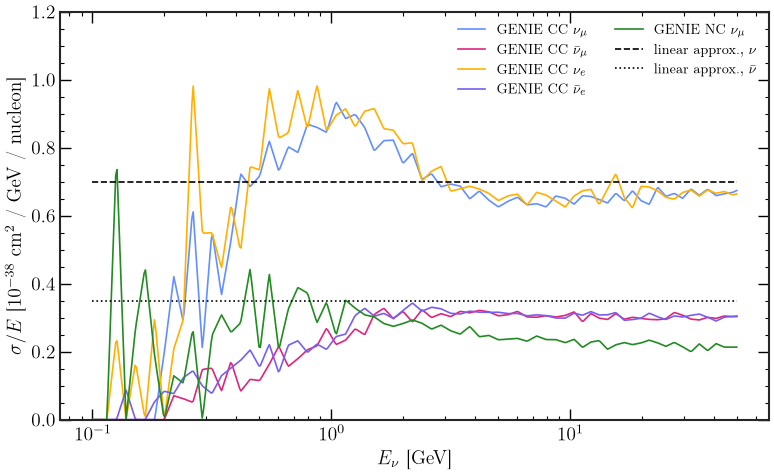

In [3]:
E = np.geomspace(0.1, 50, 500)
fig, ax = plt.subplots(figsize=(8, 5))
for i, (f, pol, lab) in enumerate([("m", "+", r"$\nu_\mu$"), ("m", "-", r"$\bar\nu_\mu$"),
                                   ("e", "+", r"$\nu_e$"), ("e", "-", r"$\bar\nu_e$")]):
    ax.plot(E, dune.xsec_at("CC", f, pol, E) / E, color=c[i], label=f"GENIE CC {lab}")
ax.plot(E, dune.xsec_at("NC", "m", "+", E) / E, color=c[4], label=r"GENIE NC $\nu_\mu$")
ax.plot(E, cross_section_cc(E) / E / 1e-38, "k--", label=r"linear approx., $\nu$")
ax.plot(E, cross_section_cc(E, True) / E / 1e-38, "k:", label=r"linear approx., $\bar\nu$")
ax.set_xscale("log")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\sigma/E$ [$10^{-38}$ cm$^2$ / GeV / nucleon]")
ax.set_ylim(0, 1.2)
ax.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

### 1b. Selection efficiencies

Fraction of events of each type that end up in each sample, vs *reconstructed* energy.
The appearance selections keep most of the $\nu_e$ CC events and reject almost all
$\nu_\mu$ CC and NC events.

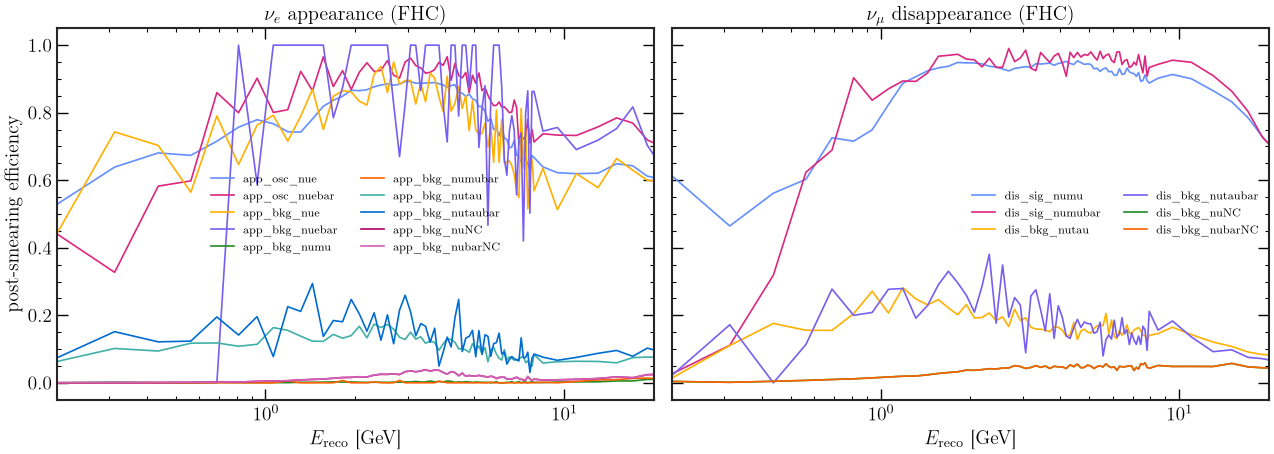

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
x = dune.E_reco
for ax, rule in zip(axes, ("nue_app", "numu_dis")):
    for i, ch in enumerate(dune.rules[rule]["signal"] + dune.rules[rule]["background"]):
        eff = dune.channels[ch]["eff"]
        if eff.max() > 0:
            ax.plot(x, eff, color=c[i % len(c)], label=ch.replace("FHC_", ""))
    ax.set_xscale("log")
    ax.set_xlim(0.2, 20)
    ax.set_xlabel(r"$E_\mathrm{reco}$ [GeV]")
    ax.set_title(SAMPLE_LABEL[rule])
    ax.legend(fontsize="x-small", ncol=2)
axes[0].set_ylabel("post-smearing efficiency")
plt.tight_layout()
plt.show()

### 1c. Energy smearing

Migration matrices $S_{ik}$: probability that an event with true energy in bin $k$ is
reconstructed in bin $i$. Muon neutrinos are reconstructed better than electron neutrinos;
NC events are reconstructed at much lower energy than their true energy (the outgoing
neutrino carries energy away).

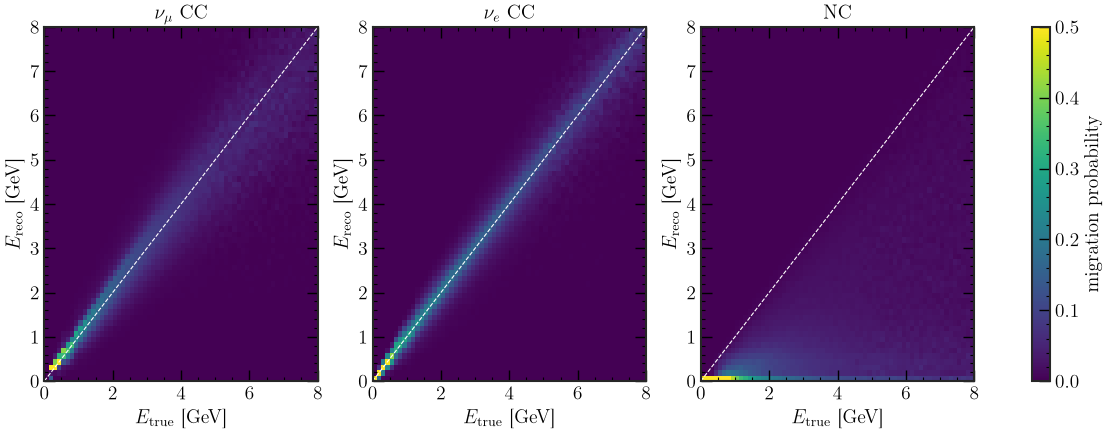

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, title) in zip(axes, [("FHC_dis_sig_numu", r"$\nu_\mu$ CC"),
                                    ("FHC_app_osc_nue", r"$\nu_e$ CC"),
                                    ("FHC_app_bkg_nuNC", "NC")]):
    S = dune.channels[name]["smear"]
    kt, kr = dune.sampling_edges <= 8.001, dune.reco_edges <= 8.001
    im = ax.pcolormesh(dune.sampling_edges[kt], dune.reco_edges[kr],
                       S[:kr.sum() - 1, :kt.sum() - 1], cmap="viridis", vmin=0, vmax=0.5)
    ax.plot([0, 8], [0, 8], "w--", lw=0.8)
    ax.set_xlabel(r"$E_\mathrm{true}$ [GeV]")
    ax.set_ylabel(r"$E_\mathrm{reco}$ [GeV]")
    ax.set_title(title)
fig.colorbar(im, ax=axes, label="migration probability")
plt.show()

## 2. Validation: reproduce Fig. 2 of the DUNE paper

Same oscillation parameters as the paper (NuFit 4.0, NO, $\delta_{CP}=0$) and the default
exposure (5 + 5 staged years = 624 kt-MW-yr). Our spectra (left, per 0.25 GeV like the paper)
should match the paper's figure (right).

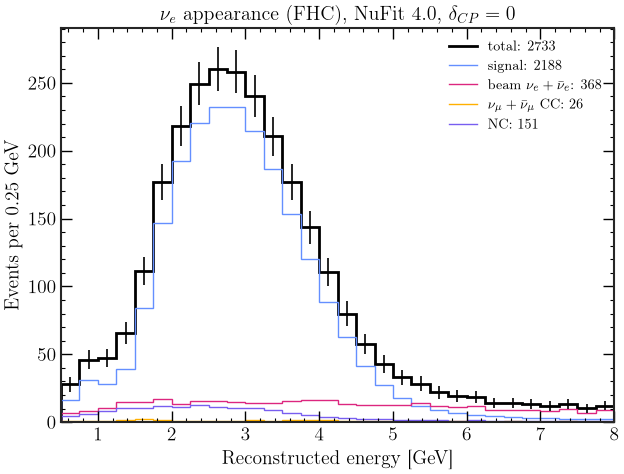

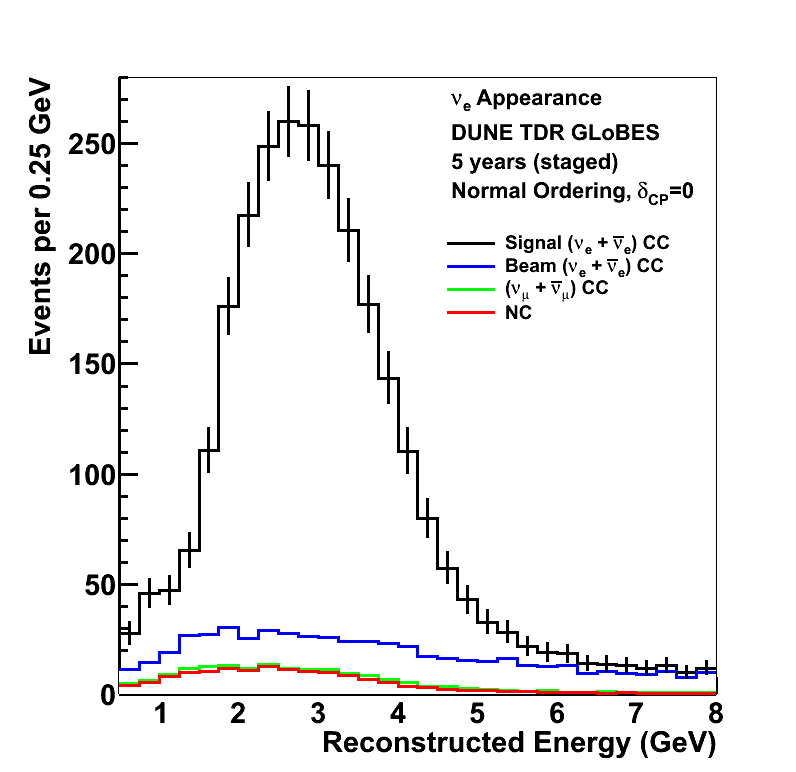

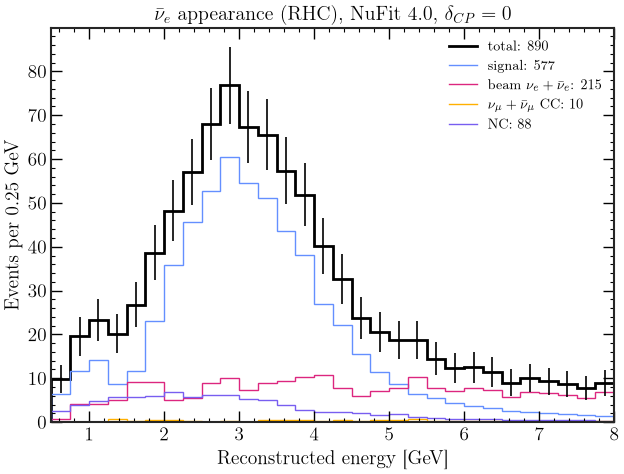

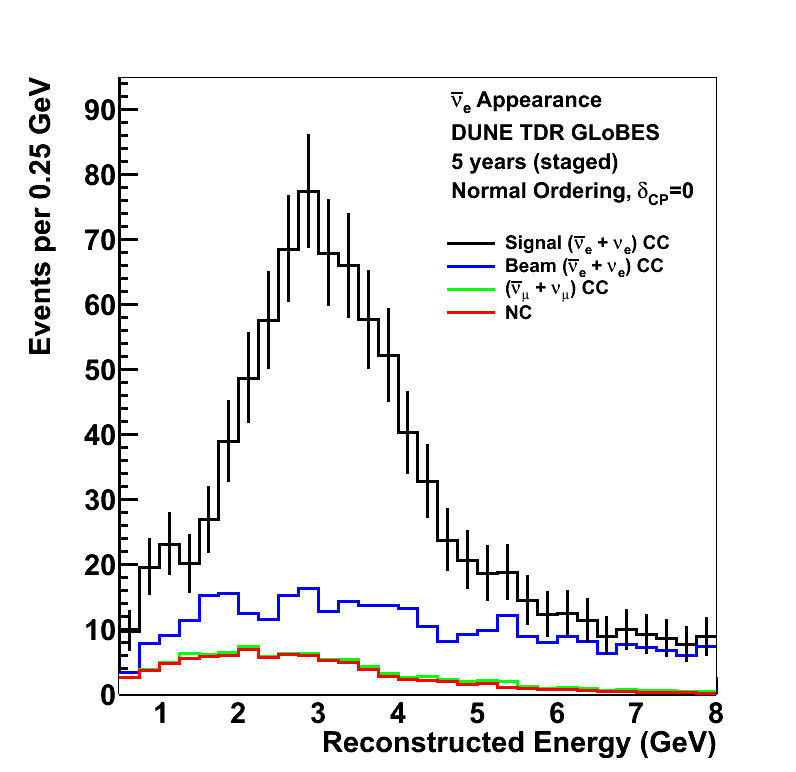

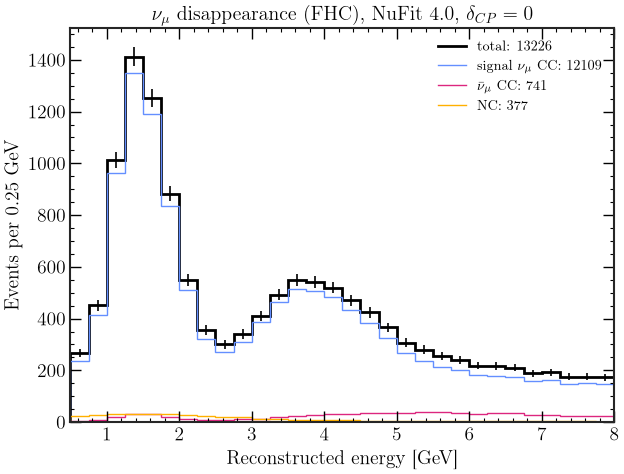

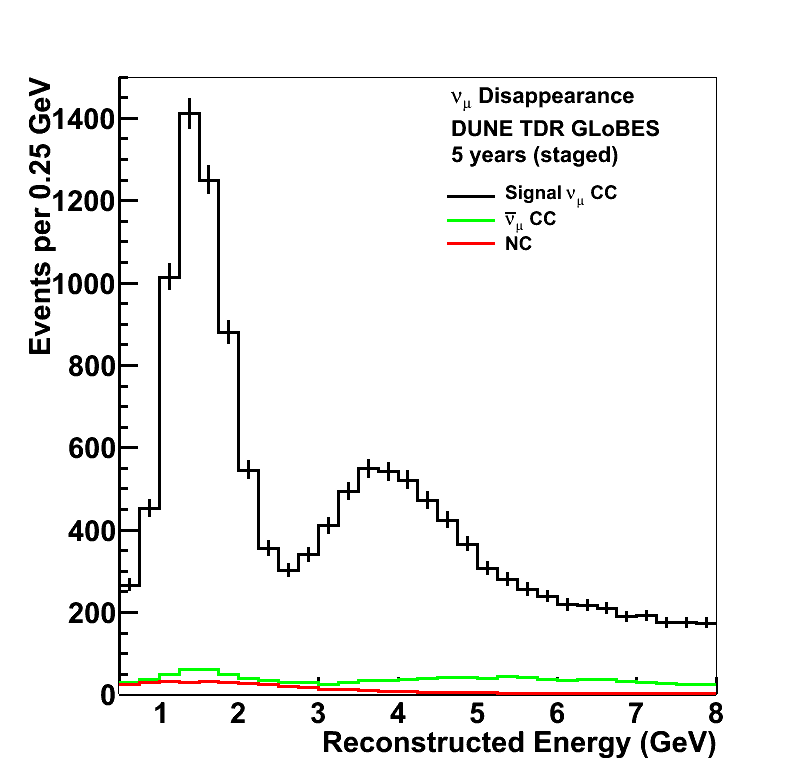

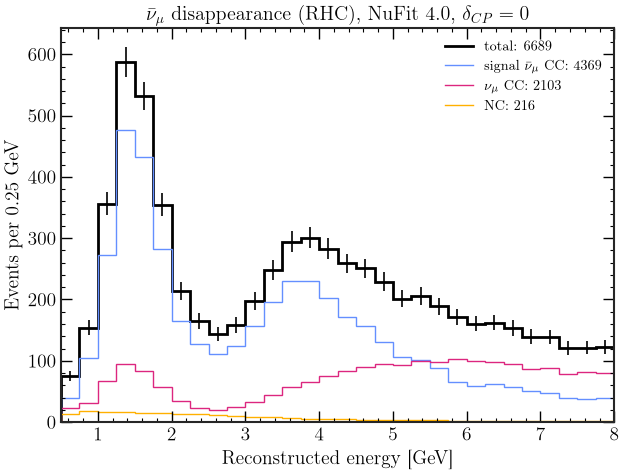

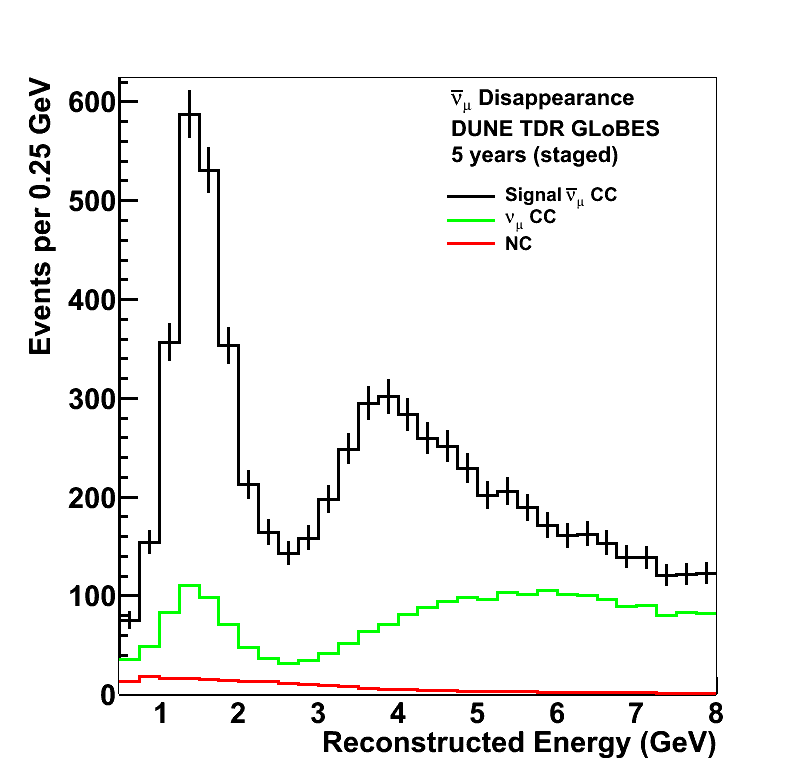

In [6]:
# NuFit 4.0 values of Table 2 of arXiv:2103.04797 (angles in radians)
nufit4 = NeutrinoOscillator("NO", s2_12=np.sin(0.5903)**2, s2_23=np.sin(0.866)**2,
                            s2_13=np.sin(0.150)**2, dm2_21=7.39e-5,
                            dm2_31=2.451e-3 + 7.39e-5, delta_cp=0.0)
dune_ref = DUNEGlobes()                      # default exposure, as in the paper
S = dune_ref.all_samples(nufit4)

def per_025(y):
    # sum pairs of 0.125-GeV bins between 0 and 8 GeV -> 0.25-GeV bins
    return y[:64].reshape(32, 2).sum(axis=1)

edges025 = np.arange(0, 8.001, 0.25)
groups = {
    "nue_app":    [("signal", ["FHC_app_osc_nue", "FHC_app_osc_nuebar"]),
                   ("beam $\\nu_e+\\bar\\nu_e$", ["FHC_app_bkg_nue", "FHC_app_bkg_nuebar"]),
                   ("$\\nu_\\mu+\\bar\\nu_\\mu$ CC", ["FHC_app_bkg_numu", "FHC_app_bkg_numubar"]),
                   ("NC", ["FHC_app_bkg_nuNC", "FHC_app_bkg_nubarNC"])],
    "nuebar_app": [("signal", ["RHC_app_osc_nue", "RHC_app_osc_nuebar"]),
                   ("beam $\\nu_e+\\bar\\nu_e$", ["RHC_app_bkg_nue", "RHC_app_bkg_nuebar"]),
                   ("$\\nu_\\mu+\\bar\\nu_\\mu$ CC", ["RHC_app_bkg_numu", "RHC_app_bkg_numubar"]),
                   ("NC", ["RHC_app_bkg_nuNC", "RHC_app_bkg_nubarNC"])],
    "numu_dis":   [("signal $\\nu_\\mu$ CC", ["FHC_dis_sig_numu"]),
                   ("$\\bar\\nu_\\mu$ CC", ["FHC_dis_sig_numubar"]),
                   ("NC", ["FHC_dis_bkg_nuNC", "FHC_dis_bkg_nubarNC"])],
    "numubar_dis": [("signal $\\bar\\nu_\\mu$ CC", ["RHC_dis_sig_numubar"]),
                    ("$\\nu_\\mu$ CC", ["RHC_dis_sig_numu"]),
                    ("NC", ["RHC_dis_bkg_nuNC", "RHC_dis_bkg_nubarNC"])],
}
paper_png = {"nue_app": "spec_app_nu_5yr.png", "nuebar_app": "spec_app_anu_5yr.png",
             "numu_dis": "spec_dis_nu_5yr.png", "numubar_dis": "spec_dis_anu_5yr.png"}

for rule in dune_ref.rules:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    s = S[rule]
    total = per_025(s["total"])
    ax.stairs(total, edges025, color="k", lw=2, label=f"total: {s['total'][:64].sum():.0f}")
    ax.errorbar(0.5 * (edges025[1:] + edges025[:-1]), total, yerr=np.sqrt(total), fmt="none", color="k")
    for i, (lab, chans) in enumerate(groups[rule]):
        y = per_025(sum(s[ch] for ch in chans))
        ax.stairs(y, edges025, color=c[i], label=f"{lab}: {y.sum():.0f}")
    ax.set_xlim(0.5, 8)
    ax.set_xlabel("Reconstructed energy [GeV]")
    ax.set_ylabel("Events per 0.25 GeV")
    ax.set_title(SAMPLE_LABEL[rule] + r", NuFit 4.0, $\delta_{CP}=0$")
    ax.legend(fontsize="small")
    plt.tight_layout()
    plt.show()
    display(Image(filename=str(PAPER_DIR / paper_png[rule]), width=420))

## 3. Predictions with NuFIT 6.0

Reconstructed spectra of the four samples for both orderings and several values of $\delta_{CP}$,
with the exposure chosen in the configuration.

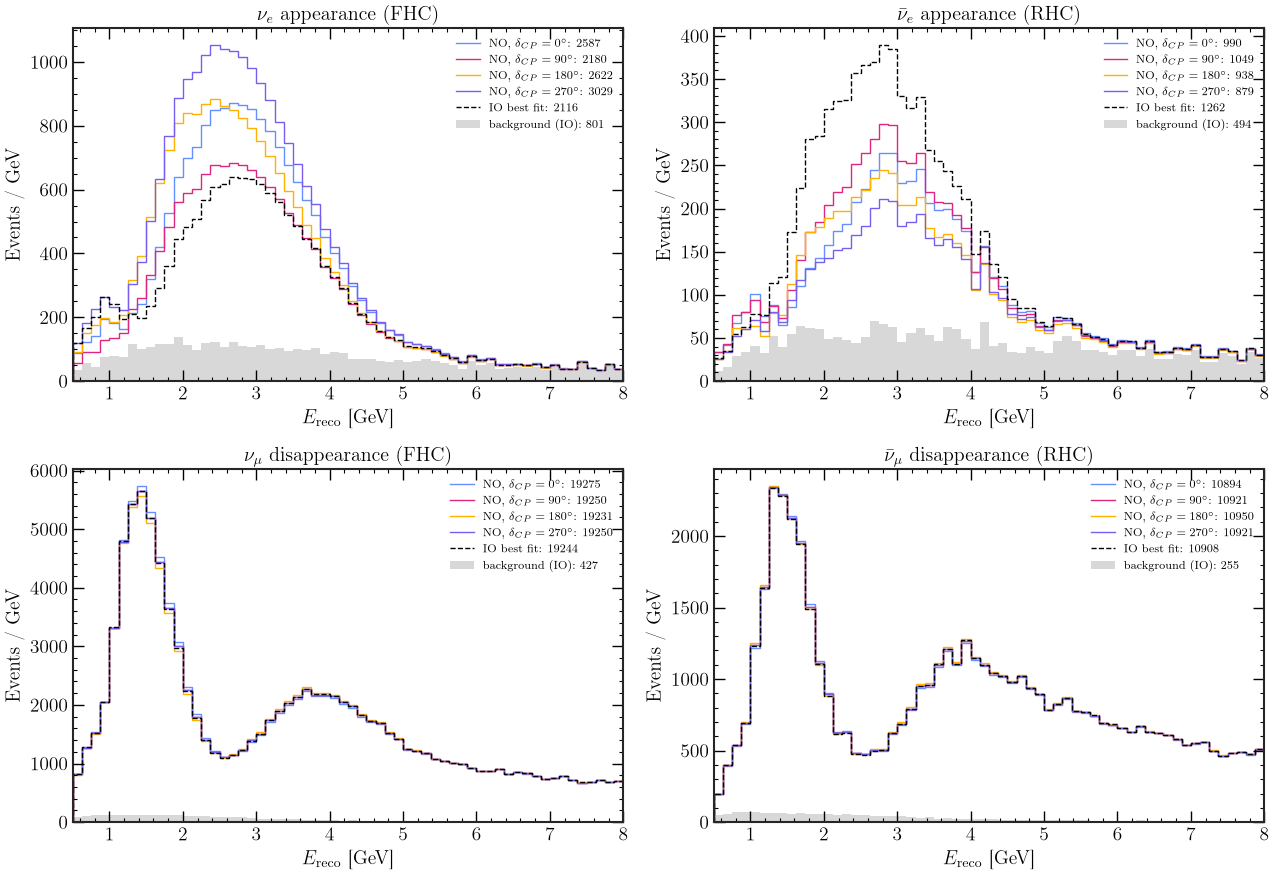

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
xr = dune.reco_edges
for ax, rule in zip(axes.ravel(), dune.rules):
    for i, d in enumerate([0, 90, 180, 270]):
        s = dune.sample(NeutrinoOscillator("NO", delta_cp=d), rule, matter=MATTER)
        ax.stairs(s["total"][:64] / 0.125, xr[:65], color=c[i],
                  label=rf"NO, $\delta_{{CP}}={d}^\circ$: {s['total'].sum():.0f}")
    s = dune.sample(NeutrinoOscillator("IO"), rule, matter=MATTER)
    ax.stairs(s["total"][:64] / 0.125, xr[:65], color="k", ls="--",
              label=f"IO best fit: {s['total'].sum():.0f}")
    ax.stairs(s["background"][:64] / 0.125, xr[:65], color="grey", fill=True, alpha=0.3,
              label=f"background (IO): {s['background'].sum():.0f}")
    ax.set_xlim(0.5, 8)
    ax.set_xlabel(r"$E_\mathrm{reco}$ [GeV]")
    ax.set_ylabel("Events / GeV")
    ax.set_title(SAMPLE_LABEL[rule])
    ax.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

## 4. How good was the simple model?

Ratio of the selected $\nu_\mu\to\nu_e$ signal from the full simulation to the "true CC, efficiency 1,
linear cross section" estimate of `nuosc.rates`, both vs *true* energy (before smearing).
It combines the cross-section difference and the selection efficiency.

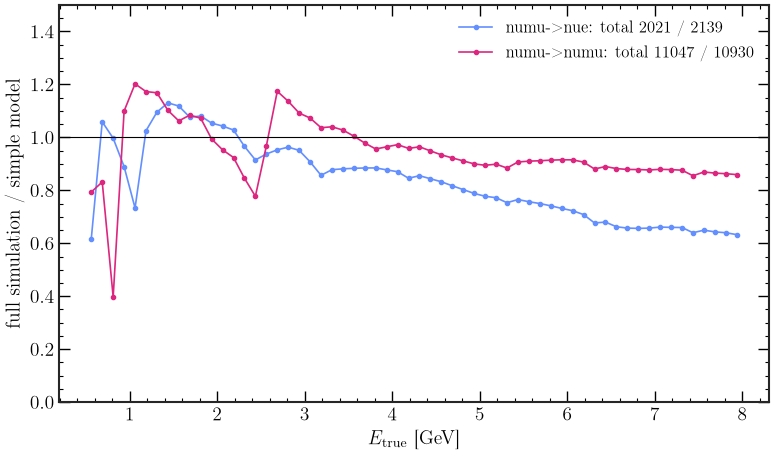

In [8]:
osc = NeutrinoOscillator("NO")
eff_true = {}
fig, ax = plt.subplots(figsize=(8, 4.8))
for i, (mode, ch, key) in enumerate([("FHC", "FHC_app_osc_nue", "numu->nue"),
                                      ("FHC", "FHC_dis_sig_numu", "numu->numu")]):
    n_globes = dune.channel_true(osc, ch, MATTER)                 # true bins, before selection
    # selected events of this channel, projected back on true energy:
    S_ = dune.channels[ch]["smear"] * dune.channels[ch]["eff"][:, None]
    n_sel_true = S_.sum(axis=0) * n_globes
    Eg = np.linspace(0.05, 20, 8000)
    _, r = expected_events("DUNE", mode, osc=osc, E=Eg, matter=MATTER, pot=dune.pot(mode),
                           mass_kt=dune.mass_kt)
    simple = histogram(Eg, r[key], dune.sampling_edges)
    m = (dune.E_true > 0.5) & (dune.E_true < 8)
    ax.plot(dune.E_true[m], n_sel_true[m] / simple[m], "o-", ms=3, color=c[i],
            label=f"{key}: total {n_sel_true[m].sum():.0f} / {simple[m].sum():.0f}")
ax.axhline(1, color="k", lw=0.8)
ax.set_xlabel(r"$E_\mathrm{true}$ [GeV]")
ax.set_ylabel("full simulation / simple model")
ax.set_ylim(0, 1.5)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sensitivity (statistics only)

A first sensitivity study, using the Asimov data set (the prediction for the "true" parameters)
and a Poisson $\chi^2$ summed over the 4 samples and all reconstructed bins:
$$\chi^2 = 2\sum_i \left[\mu_i - n_i + n_i\ln\frac{n_i}{\mu_i}\right].$$

* **CP violation:** for each true $\delta_{CP}$, the smallest $\Delta\chi^2$ obtained with
  $\delta_{CP}^\mathrm{test} = 0$ or $\pi$ (both orderings tested).
* **Mass ordering:** true NO, test IO, minimised over $\delta_{CP}^\mathrm{test}$ and $|\Delta m^2_{31}|$.

All other parameters are kept fixed and there are **no systematic uncertainties**, so these
curves are more optimistic than the official ones (shown below, which include systematics
and marginalise over all parameters).

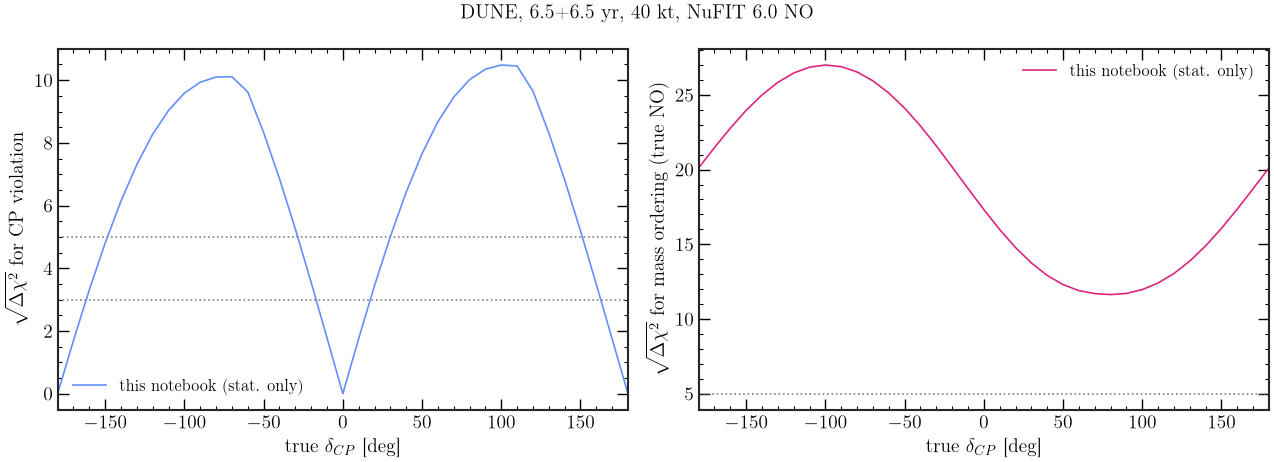

Official DUNE sensitivities (with systematics, arXiv:2103.04797):


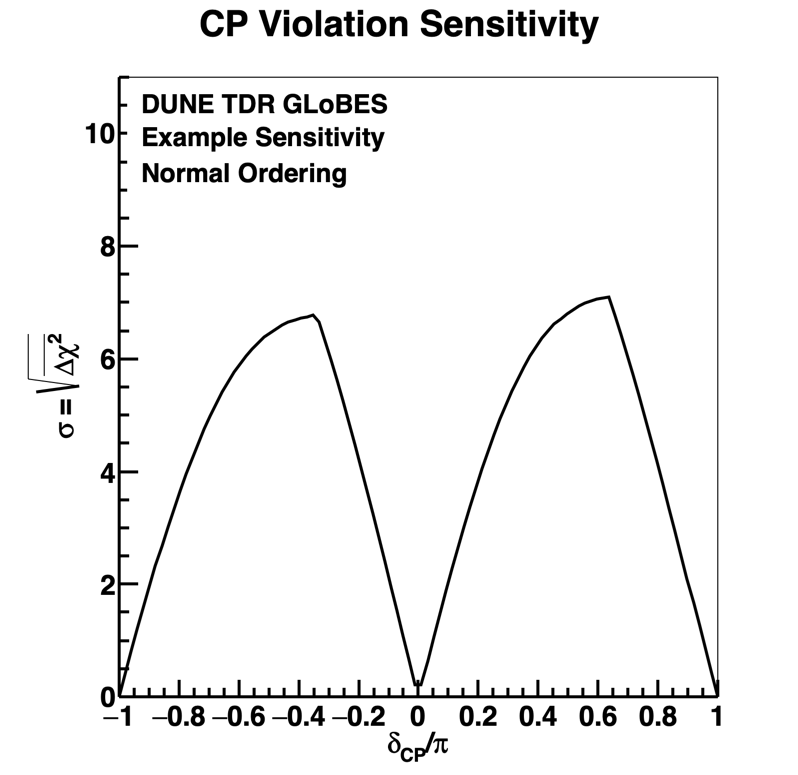

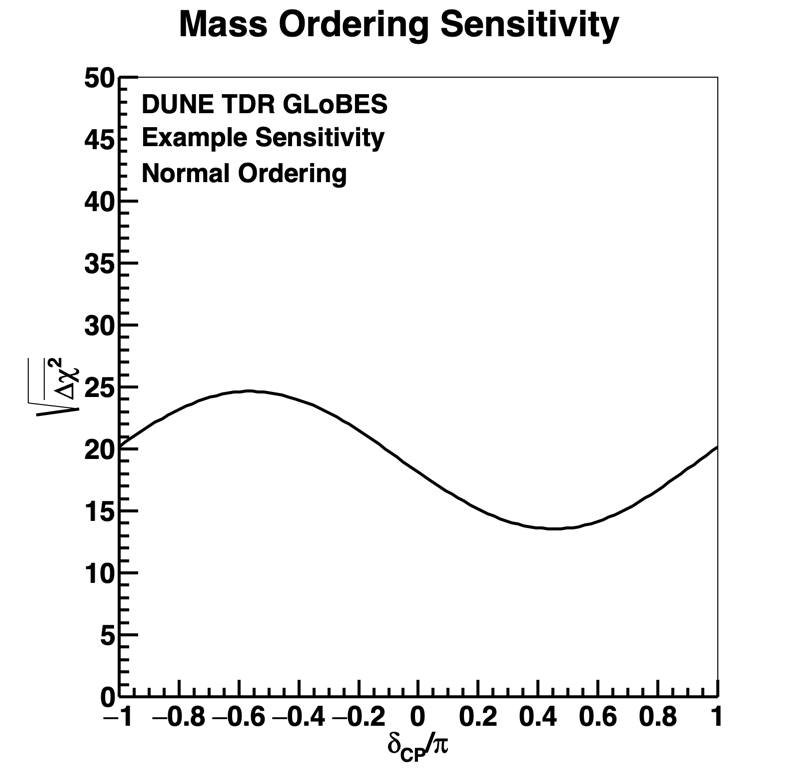

In [9]:
def chi2_poisson(n, mu):
    n, mu = np.asarray(n), np.maximum(np.asarray(mu), 1e-12)
    return 2 * np.sum(mu - n + np.where(n > 0, n * np.log(np.where(n > 0, n, 1) / mu), 0))

def spectra(osc):
    return np.concatenate([s["total"] for s in dune.all_samples(osc, matter=MATTER).values()])

def chi2(true_spec, osc_test):
    return chi2_poisson(true_spec, spectra(osc_test))

true_deltas = np.linspace(-180, 180, 37)
no, io = NeutrinoOscillator("NO"), NeutrinoOscillator("IO")

sqrt_cpv, sqrt_mo = [], []
for d in true_deltas:
    true = spectra(NeutrinoOscillator("NO", delta_cp=d))
    # CPV: test delta = 0, 180 (both orderings)
    c2 = [chi2(true, NeutrinoOscillator(o, delta_cp=dt)) for o in ("NO", "IO") for dt in (0, 180)]
    sqrt_cpv.append(np.sqrt(min(c2)))
    # MO: test IO, minimise over delta and |dm2_31|
    best = np.inf
    for dt in np.linspace(0, 360, 25, endpoint=False):
        for dm in np.linspace(-2.56e-3, -2.36e-3, 11):
            best = min(best, chi2(true, NeutrinoOscillator("IO", delta_cp=dt, dm2_31=dm)))
    sqrt_mo.append(np.sqrt(best))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(true_deltas, sqrt_cpv, color=c[0], label="this notebook (stat. only)")
axes[0].axhline(3, color="grey", ls=":"); axes[0].axhline(5, color="grey", ls=":")
axes[0].set_ylabel(r"$\sqrt{\Delta\chi^2}$ for CP violation")
axes[1].plot(true_deltas, sqrt_mo, color=c[1], label="this notebook (stat. only)")
axes[1].axhline(5, color="grey", ls=":")
axes[1].set_ylabel(r"$\sqrt{\Delta\chi^2}$ for mass ordering (true NO)")
for ax in axes:
    ax.set_xlabel(r"true $\delta_{CP}$ [deg]")
    ax.set_xlim(-180, 180)
    ax.legend()
fig.suptitle(f"DUNE, {dune.years['FHC']:g}+{dune.years['RHC']:g} yr, {dune.mass_kt:g} kt, NuFIT 6.0 NO")
plt.tight_layout()
plt.show()

print("Official DUNE sensitivities (with systematics, arXiv:2103.04797):")
display(Image(filename=str(PAPER_DIR / "cpv_globes.png"), width=420))
display(Image(filename=str(PAPER_DIR / "mh_globes.png"), width=420))

### Things to try

* Change `YEARS_FHC`, `YEARS_RHC` or `MASS_KT` and watch the sensitivity grow like $\sqrt{\text{exposure}}$.
* Switch `MATTER = False`: what happens to the mass-ordering sensitivity?
* Add simple normalisation systematics (the paper uses 2% on the $\nu_e$ signal, 5% on the $\nu_\mu$
  signal, 5–20% on backgrounds; see `definitions.inc`) as pull terms in the $\chi^2$.